In [ ]:
# Library 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
# Load the economic freedom index dataset
freedom_df = pd.read_csv('freedom_index.csv')

In [3]:
# Inspect the first few rows
print(freedom_df.head())

   Year  Countries  Economic Freedom Index
0  2015    Albania                    7.64
1  2015    Algeria                    4.68
2  2015     Angola                    5.25
3  2015  Argentina                    4.95
4  2015    Armenia                    7.43


In [4]:
freedom_df.rename(columns={'Countries': 'Country'} , inplace=True)

In [5]:
# Check for missing values
print(freedom_df.isnull().sum())

Year                      0
Country                   0
Economic Freedom Index    0
dtype: int64


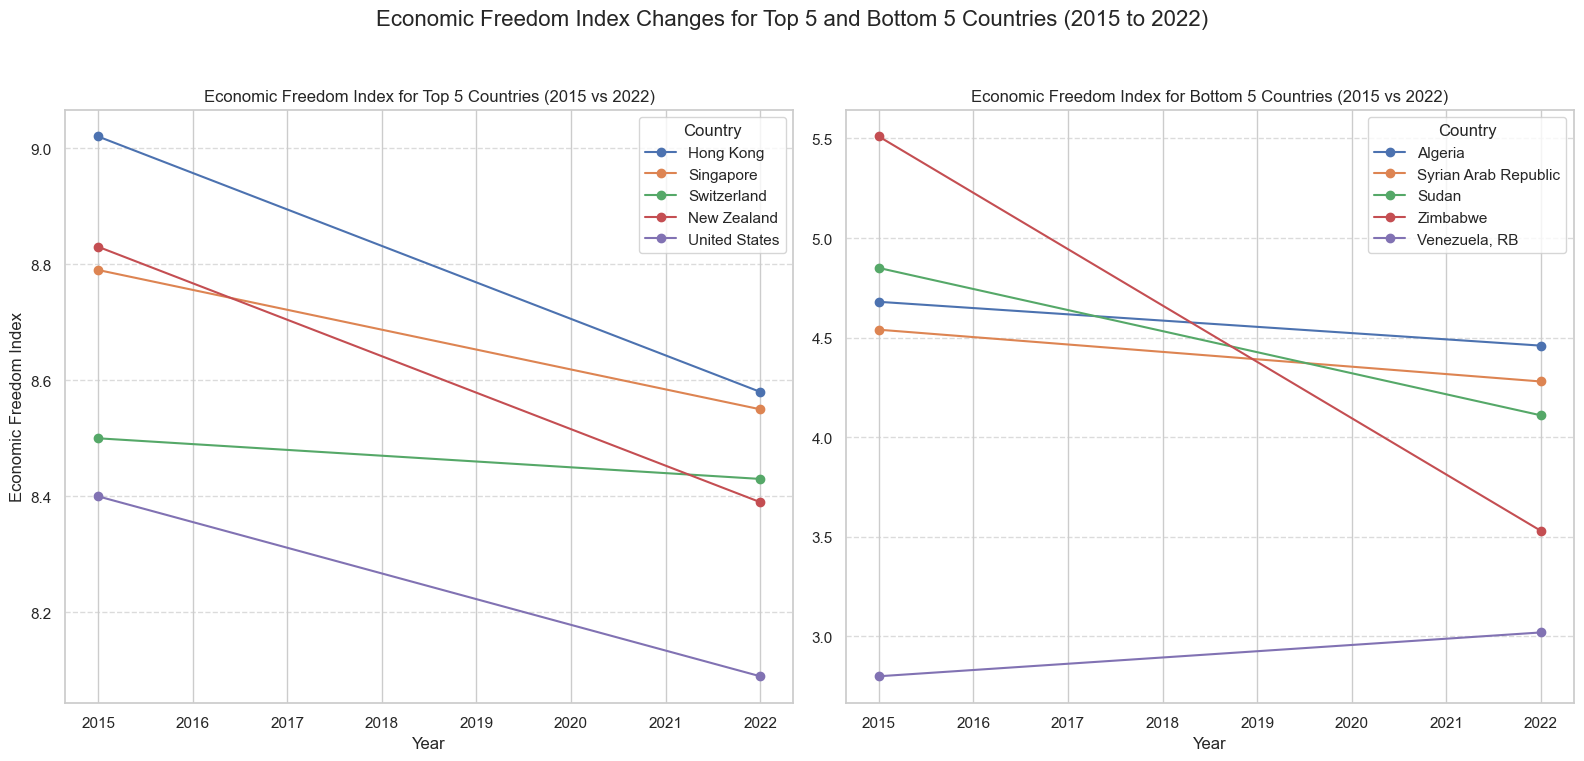

In [ ]:
# Economic Freedom Index Changes for Top 5 and Bottom 5 Countries (2015 to 2022)

# Filter data for 2015 and 2022 for top 5 and bottom 5 ranking countries
top_5_countries_2022 = freedom_df[freedom_df['Year'] == 2022].sort_values(by='Economic Freedom Index', ascending=False).head(5)['Country'].tolist()
bottom_5_countries_2022 = freedom_df[freedom_df['Year'] == 2022].sort_values(by='Economic Freedom Index', ascending=False).tail(5)['Country'].tolist()

# Filter data for the selected countries in both years
selected_years = [2015, 2022]
filtered_df_top = freedom_df[(freedom_df['Country'].isin(top_5_countries_2022)) & (freedom_df['Year'].isin(selected_years))]
filtered_df_bottom = freedom_df[(freedom_df['Country'].isin(bottom_5_countries_2022)) & (freedom_df['Year'].isin(selected_years))]

# Set a style for the plot
sns.set(style="whitegrid")

# Create subplots for Top 5 and Bottom 5 ranking countries
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot for top 5 countries
for country in top_5_countries_2022:
    data = filtered_df_top[filtered_df_top['Country'] == country]
    axes[0].plot(data['Year'], data['Economic Freedom Index'], marker='o', label=country)

axes[0].set_title('Economic Freedom Index for Top 5 Countries (2015 vs 2022)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Economic Freedom Index')
axes[0].legend(title='Country')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for bottom 5 countries
for country in bottom_5_countries_2022:
    data = filtered_df_bottom[filtered_df_bottom['Country'] == country]
    axes[1].plot(data['Year'], data['Economic Freedom Index'], marker='o', label=country)

axes[1].set_title('Economic Freedom Index for Bottom 5 Countries (2015 vs 2022)')
axes[1].set_xlabel('Year')
axes[1].legend(title='Country')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Customize layout and show plot
plt.suptitle('Economic Freedom Index Changes for Top 5 and Bottom 5 Countries (2015 to 2022)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In the left graph, we see the Economic Freedom Index trends for the top 5 countries, including Hong Kong, Singapore, Switzerland, New Zealand, and the United States, between the years 2015 and 2022. The y-axis represents the Economic Freedom Index, while the x-axis represents the years 2015 and 2022. The graph reveals an overall downward trend in the Economic Freedom Index for all five countries. Hong Kong and Singapore, in particular, show noticeable declines over this period. The decline in Hong Kong’s economic freedom could potentially be attributed to increased political influence from mainland China, leading to changes in policies that negatively impacted the business environment and market regulations. Singapore’s decline, while not as steep as Hong Kong's, could be influenced by regulatory shifts and the impact of global economic uncertainties that affected its typically open economy.

New Zealand and the United States also show a decrease in their Economic Freedom Index values. The United States faced challenges such as trade policy shifts, increased government spending, and regulatory changes during this period, which might have contributed to its decline in economic freedom. Switzerland, while seeing a smaller drop compared to other top countries, faced pressures in maintaining its economic freedom, potentially due to a need for increased oversight and regulatory adaptations in the financial sector.

In contrast, the right graph focuses on the bottom 5 countries from 2022, specifically Algeria, Syrian Arab Republic, Sudan, Zimbabwe, and Venezuela, over the same time frame. The y-axis again represents the Economic Freedom Index, and the x-axis shows the years 2015 and 2022. For these countries, the trend is also downward, but the differences are more striking. Zimbabwe and Sudan show significant declines, indicating worsening economic conditions. The deterioration in economic freedom for these countries could be attributed to ongoing political instability, hyperinflation, and weak governance, which collectively undermine economic policies that support freedom.

Venezuela, in particular, experienced the sharpest decline, primarily due to economic mismanagement, hyperinflation, and an increasingly authoritarian government, which has severely restricted market freedom and business operations. The Syrian Arab Republic also faced severe challenges stemming from prolonged conflict, which not only disrupted its economy but also led to increased government control and intervention.

Comparing the two charts, it becomes evident that while both groups of countries experienced declines, the nature of these changes is notably different. The top 5 countries, despite their decline, were better positioned to manage economic challenges, and their decreases were less severe. In contrast, the bottom 5 countries faced deep-rooted challenges, including political instability and poor governance, which significantly impacted their economic freedom. The difference in the severity of declines between the two groups highlights the widening disparity in economic freedom between already economically free nations and those struggling to achieve it.

This insight points towards the need for targeted policy reforms and support for nations with low economic freedom to improve governance, stabilize political conditions, and foster market-friendly environments.

Introduction to World Happiness Dataset:

The World Happiness dataset, also known as the World Happiness Report, collects data annually to evaluate global well-being based on individuals’ assessments of their lives. The dataset includes the "Life Ladder" score, which is a measure of subjective well-being, ranging from 0 to 10. This score reflects how people rate their quality of life, with higher scores indicating greater happiness or satisfaction. The data is gathered through surveys and is widely used to understand the factors contributing to well-being across different nations.

Why Use the World Happiness Dataset for Economic Freedom Analysis:

In this analysis, we use the World Happiness dataset to explore the connection between economic freedom and subjective well-being. The Economic Freedom Index, which reflects the extent to which policies and institutions support free economic activity, plays a vital role in shaping people's lives, impacting job opportunities, income security, and overall living conditions. By integrating the World Happiness dataset, we can better understand if, and how, economic freedom translates into happiness.

Our analysis aims to see if higher economic freedom, characterized by open markets, personal choice, and limited government intervention, is linked to higher life satisfaction among citizens. Understanding this relationship allows us to gauge the effectiveness of policies promoting economic freedom and their tangible impact on people's quality of life. It also provides insights into whether countries with greater economic liberties tend to create more fulfilling environments for their citizens.

In [7]:
# Load the world happiness dataset
happiness_df = pd.read_csv('happiness-cantril-ladder.csv')

In [8]:
# Drop the 'Code' column
happiness_df.drop(columns=['Code'], inplace=True)


In [9]:
# Drop rows with missing values in key columns
happiness_df.dropna(subset=['Cantril ladder score'], inplace=True)

In [10]:
# Rename columns for better readability
happiness_df.rename(columns={'Entity': 'Country', 'Cantril ladder score': 'Life Ladder'}, inplace=True)

In [11]:
# check missing value
happiness_df.isna().sum()

Country        0
Year           0
Life Ladder    0
dtype: int64

In [12]:
# Merge the two dataframes on 'Year' and 'Country'
fh_merged_df = pd.merge(freedom_df, happiness_df, how='inner', on=['Year', 'Country'])

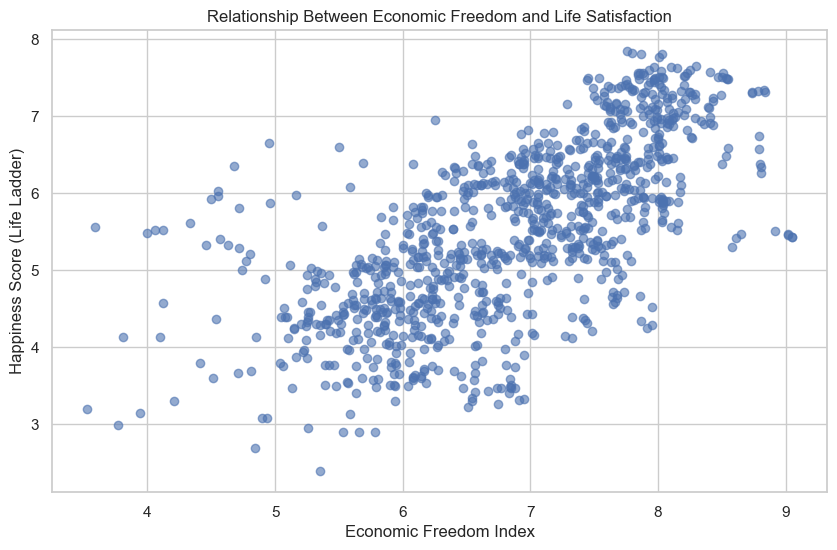

In [13]:
# Scatter plot for the relationship between Economic Freedom and Happiness
plt.figure(figsize=(10, 6))
plt.scatter(fh_merged_df['Economic Freedom Index'], fh_merged_df['Life Ladder'], alpha=0.6)
plt.xlabel('Economic Freedom Index')
plt.ylabel('Happiness Score (Life Ladder)')
plt.title('Relationship Between Economic Freedom and Life Satisfaction')
plt.grid(True)
plt.show()

This scatter plot illustrates the relationship between economic freedom and happiness across different countries from 2015 to 2022. The x-axis represents the Economic Freedom Index, while the y-axis represents the Happiness Score (also known as the Life Ladder score). Each point represents a country, showing the correlation between the degree of economic freedom and perceived happiness.

From the visualization, there is a clear positive trend, suggesting that countries with higher economic freedom tend to have higher happiness scores. This correlation highlights how economic policies that promote freedom—such as open markets, property rights, and lower government intervention—can contribute to greater overall well-being and satisfaction among citizens. However, it's also visible that there is some variability, implying that while economic freedom is influential, other factors also impact happiness in different nations.



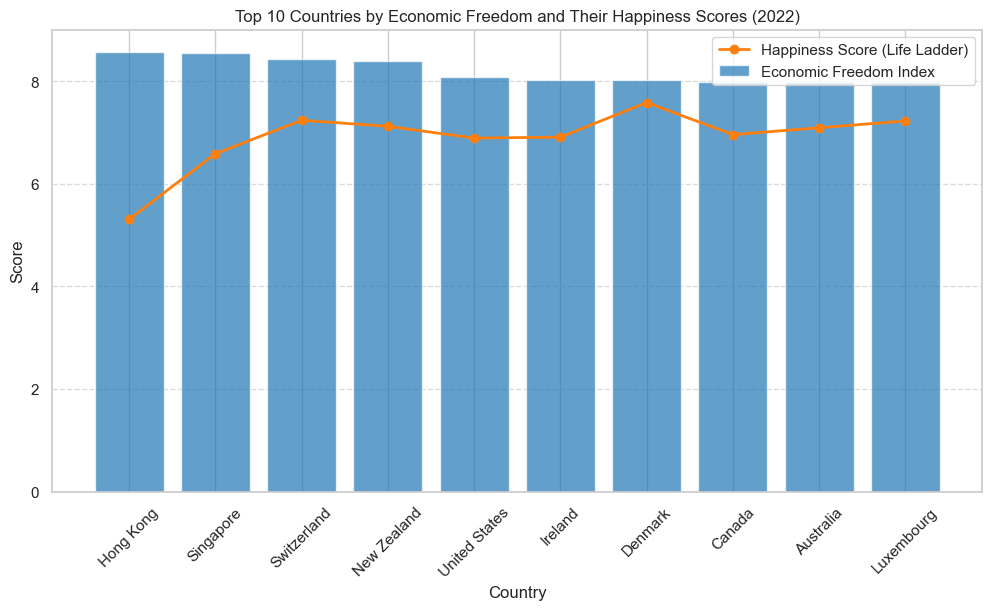

In [14]:
#Top 10 Countries by Economic Freedom and Their Happiness Scores (2022)

# Filter data for 2022
fh_2022 = fh_merged_df[fh_merged_df['Year'] == 2022]

# Sort by Economic Freedom Index and select top 10 countries
top_10_2022 = fh_2022.sort_values(by='Economic Freedom Index', ascending=False).head(10)

# Define colorblind-friendly colors
color_blind_palette = mcolors.TABLEAU_COLORS

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_10_2022['Country'], top_10_2022['Economic Freedom Index'], alpha=0.7, label='Economic Freedom Index', color=color_blind_palette['tab:blue'])
plt.plot(top_10_2022['Country'], top_10_2022['Life Ladder'], color=color_blind_palette['tab:orange'], marker='o', linewidth=2, label='Happiness Score (Life Ladder)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.title('Top 10 Countries by Economic Freedom and Their Happiness Scores (2022)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In our analysis, we have constructed a bar and line chart that succinctly visualizes two key metrics for the top 10 countries by economic freedom in 2022: the Economic Freedom Index and the Happiness Score (Life Ladder). The chart is organized with the countries displayed along the x-axis, while the y-axis represents their respective scores for both metrics. Economic freedom is represented by the blue bars, and happiness scores are depicted by the orange line.

One significant insight from the visualization is the consistency in the Economic Freedom Index among the top-performing countries, with scores generally above 8. Countries like Hong Kong, Singapore, Switzerland, and New Zealand demonstrate stability in their economic freedom, which may contribute to their citizens' high quality of life. Another observation is that while the Economic Freedom Index scores are relatively uniform across these top countries, happiness scores show more variability, indicating that economic freedom alone does not fully determine happiness levels.

It is also notable that Hong Kong and Singapore, despite leading in economic freedom, exhibit comparatively lower happiness scores. This discrepancy suggests that while economic freedom is critical, other factors such as social stability, political climate, or cultural influences may significantly impact overall well-being. In the case of Hong Kong and Singapore, intense work culture, high population density, and socio-political pressures could contribute to a lower happiness perception, even though the citizens enjoy substantial economic freedoms.

For instance, Ireland exhibits a higher happiness score compared to other countries with similar economic freedom levels, such as Luxembourg or Hong Kong. This highlights the influence of non-economic factors, such as social safety nets, community engagement, or public services, which may also significantly impact happiness. Similarly, although the United States and New Zealand have similar economic freedom scores, New Zealand's slightly higher happiness score suggests that factors beyond economic freedom contribute to overall well-being.

This analysis underscores the importance of adopting a multifaceted approach to enhance citizens' quality of life. Economic freedom is certainly a critical factor, but other aspects like healthcare, education, social cohesion, and community support are also crucial in improving happiness and well-being at the national level.
